# Multi-Objective Optimization for German Credit Risk
This notebook implements a Multi-Objective Optimization (MOO) pipeline to optimize a credit risk model (XGBoost) across three conflicting objectives:
1. **Accuracy (Maximize)**: Overall classification correctness.
2. **Fairness (Minimize DPD)**: Demographic Parity Difference between male and female groups.
3. **Expected Profit (Maximize)**: Based on an asymmetric cost matrix (+1 for correct approval/rejection, -5 for incorrect approval/default).

We implement and compare two MOO algorithms:
- **Optuna NSGA-II**
- **PyMOO NSGA-III**


In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import optuna
import plotly.express as px
import plotly.graph_objects as go
import random
import os
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.optimize import minimize
from pymoo.indicators.hv import HV
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
os.makedirs("plots", exist_ok=True)

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Load data
DATA_PATH = 'data/german_credit_data_cleaned.csv'
df = pd.read_csv(DATA_PATH)
y = df['Risk_good'].values
X_full = df.drop(columns=['Risk_good'])
sensitive = df['Sex_male'].values


c:\Users\modan\OneDrive - iiit-b\Sem8\MOML-8-AIT-846\project\German_Credit_MOML\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Custom Objective and Evaluation Functions
We use a custom objective function during XGBoost training to incorporate a fairness penalty (controlled by `alpha_fair`). The classification threshold is also a decision variable.


In [2]:
def make_custom_obj(sens_array, alpha_fair=0.5):
    '''Custom XGBoost objective combining log-loss and fairness penalty.'''
    def custom_obj(preds, dmatrix):
        labels = dmatrix.get_label()
        preds_prob = 1.0 / (1.0 + np.exp(-preds))
        
        # Log-loss gradients
        grad_log = preds_prob - labels
        hess_log = preds_prob * (1.0 - preds_prob)
        
        # Fairness gradients (Demographic Parity)
        mask_p = (sens_array == 1)
        mask_u = (sens_array == 0)
        n_p, n_u = mask_p.sum(), mask_u.sum()
        
        mean_p = preds_prob[mask_p].mean() if n_p > 0 else 0
        mean_u = preds_prob[mask_u].mean() if n_u > 0 else 0
        diff = mean_p - mean_u
        sign = np.sign(diff)
        
        sigmoid_deriv = preds_prob * (1.0 - preds_prob)
        grad_fair = np.zeros_like(preds)
        
        if n_p > 0: grad_fair[mask_p] = sign * (1.0 / n_p) * sigmoid_deriv[mask_p]
        if n_u > 0: grad_fair[mask_u] = -sign * (1.0 / n_u) * sigmoid_deriv[mask_u]
        
        hess_fair = np.zeros_like(preds) # simplified
        
        grad = (1 - alpha_fair) * grad_log + alpha_fair * grad_fair
        hess = (1 - alpha_fair) * hess_log + alpha_fair * hess_fair
        return grad, hess
    return custom_obj

def evaluate_model(params, alpha_fair, threshold, seed=GLOBAL_SEED):
    '''Evaluates a configuration using 3-fold CV. Returns (accuracy, dpd, profit).'''
    kf = KFold(n_splits=3, shuffle=True, random_state=seed)
    acc_scores, dpd_scores, profit_scores = [], [], []

    for train_idx, val_idx in kf.split(X_full):
        X_train = X_full.iloc[train_idx].drop(columns=['Sex_male']).values
        y_train, sens_train = y[train_idx], sensitive[train_idx]
        
        X_val = X_full.iloc[val_idx].drop(columns=['Sex_male']).values
        y_val, sens_val = y[val_idx], sensitive[val_idx]

        train_obj = make_custom_obj(sens_train, alpha_fair=alpha_fair)
        dtrain = xgb.DMatrix(X_train, label=y_train)
        dval = xgb.DMatrix(X_val, label=y_val)

        bst = xgb.train(
            params, dtrain, num_boost_round=100, obj=train_obj,
            evals=[(dtrain, 'train'), (dval, 'val')],
            early_stopping_rounds=10, verbose_eval=False
        )

        pred_prob = bst.predict(dval)
        pred = (pred_prob > threshold).astype(int)

        # 1. Accuracy
        acc = accuracy_score(y_val, pred)
        
        # 2. Fairness (DPD)
        dpd = abs(pred[sens_val == 1].mean() - pred[sens_val == 0].mean())
        
        # 3. Expected Profit
        # Cost matrix: True Positive (+1), True Negative (+1), False Positive/Default (-5), False Negative (0)
        profit = 0
        for i in range(len(y_val)):
            if y_val[i] == 1 and pred[i] == 1: profit += 1 # Good loan approved
            elif y_val[i] == 0 and pred[i] == 0: profit += 1 # Bad loan rejected
            elif y_val[i] == 0 and pred[i] == 1: profit -= 5 # Bad loan approved (DEFAULT)
            # Good loan rejected = 0 (missed opportunity)
        
        avg_profit = profit / len(y_val)

        acc_scores.append(acc)
        dpd_scores.append(dpd)
        profit_scores.append(avg_profit)

    return np.mean(acc_scores), np.mean(dpd_scores), np.mean(profit_scores)


## Algorithm 1: Optuna NSGA-II
We use Optuna's `NSGAIISampler` to optimize the 3 objectives over 200 trials.


In [3]:
def optuna_objective(trial):
    max_depth = trial.suggest_int('max_depth', 3, 7)
    eta = trial.suggest_float('eta', 0.01, 0.3)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    
    alpha_fair = trial.suggest_float('alpha_fair', 0.0, 1.0)
    threshold = trial.suggest_float('threshold', 0.3, 0.7)
    
    params = {
        'max_depth': max_depth,
        'eta': eta,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'verbosity': 0,
        'seed': GLOBAL_SEED + trial.number
    }
    
    acc, dpd, profit = evaluate_model(params, alpha_fair, threshold)
    
    trial.set_user_attr('params', params)
    trial.set_user_attr('alpha_fair', alpha_fair)
    trial.set_user_attr('threshold', threshold)
    
    # Optuna maximizes accuracy, minimizes DPD, maximizes profit
    return acc, dpd, profit

# Run Optuna Study
sampler = optuna.samplers.NSGAIISampler(seed=GLOBAL_SEED)
study = optuna.create_study(directions=['maximize', 'minimize', 'maximize'], sampler=sampler)
study.optimize(optuna_objective, n_trials=200, show_progress_bar=True)

# Extract Pareto front
optuna_results = []
for trial in study.best_trials:
    optuna_results.append({
        'Algorithm': 'Optuna NSGA-II',
        'Accuracy': trial.values[0],
        'DPD': trial.values[1],
        'Profit': trial.values[2],
        'alpha_fair': trial.user_attrs['alpha_fair'],
        'threshold': trial.user_attrs['threshold']
    })
df_optuna = pd.DataFrame(optuna_results)
print(f"Optuna found {len(df_optuna)} Pareto-optimal solutions.")


[I 2026-04-26 16:15:42,071] A new study created in memory with name: no-name-b63559ac-9e5f-419b-bd32-611456159034
  0%|          | 1/200 [00:00<00:57,  3.46it/s]

[I 2026-04-26 16:15:42,361] Trial 0 finished with values: [0.7035823584012646, 0.08580452714019278, 0.36433203750846266] and parameters: {'max_depth': 4, 'eta': 0.28570714885887566, 'subsample': 0.892797576724562, 'colsample_bytree': 0.8394633936788146, 'alpha_fair': 0.15601864044243652, 'threshold': 0.362397808134481}.
[I 2026-04-26 16:15:42,456] Trial 1 finished with values: [0.65358281791363, 0.04498832284795017, 0.4072076046233071] and parameters: {'max_depth': 3, 'eta': 0.2611910822747312, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184181, 'alpha_fair': 0.020584494295802447, 'threshold': 0.6879639408647977}.


  2%|▏         | 4/200 [00:00<00:27,  7.02it/s]

[I 2026-04-26 16:15:42,575] Trial 2 finished with values: [0.6835736583004782, 0.0537630692361038, 0.3871115971730799] and parameters: {'max_depth': 7, 'eta': 0.07157834209670008, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'alpha_fair': 0.3042422429595377, 'threshold': 0.5099025726528951}.
[I 2026-04-26 16:15:42,695] Trial 3 finished with values: [0.6842920292985085, 0.063337518464178, 0.3735697677624505] and parameters: {'max_depth': 5, 'eta': 0.09445645065743215, 'subsample': 0.8447411578889518, 'colsample_bytree': 0.6557975442608167, 'alpha_fair': 0.29214464853521815, 'threshold': 0.4465447373174767}.


  3%|▎         | 6/200 [00:00<00:27,  7.07it/s]

...

[I 2026-04-26 16:16:13,630] Trial 195 finished with values: [0.7207068525547355, 0.08410208773040119, 0.38138760480711204] and parameters: {'max_depth': 7, 'eta': 0.17100823536384407, 'subsample': 0.8217416210045603, 'colsample_bytree': 0.6967409163601807, 'alpha_fair': 0.03142918568673425, 'threshold': 0.3341389859975072}.
[I 2026-04-26 16:16:13,796] Trial 196 finished with values: [0.5000061268315397, 0.0, 0.5000061268315397] and parameters: {'max_depth': 7, 'eta': 0.06056626441144752, 'subsample': 0.8763750952409863, 'colsample_bytree': 0.9474396512757841, 'alpha_fair': 0.9856504541106007, 'threshold': 0.39682210860460015}.


100%|█████████▉| 199/200 [00:32<00:00,  4.32it/s]

[I 2026-04-26 16:16:14,063] Trial 197 finished with values: [0.6742838499784028, 0.07046006494648917, 0.5064239828693791] and parameters: {'max_depth': 7, 'eta': 0.059451995869314544, 'subsample': 0.6894383354077811, 'colsample_bytree': 0.8446882984937409, 'alpha_fair': 0.03142918568673425, 'threshold': 0.6852890157762445}.
[I 2026-04-26 16:16:14,249] Trial 198 finished with values: [0.6807216182187462, 0.03380816989341506, 0.2771012734619355] and parameters: {'max_depth': 4, 'eta': 0.2773435281567039, 'subsample': 0.8807867509030813, 'colsample_bytree': 0.9183170677744404, 'alpha_fair': 0.8900053418175663, 'threshold': 0.32542334011440943}.


100%|██████████| 200/200 [00:32<00:00,  6.18it/s]


[I 2026-04-26 16:16:14,438] Trial 199 finished with values: [0.6750114112237426, 0.0445330179580072, 0.3000340039150453] and parameters: {'max_depth': 6, 'eta': 0.28663928733075034, 'subsample': 0.9659457560881795, 'colsample_bytree': 0.7546941385202149, 'alpha_fair': 0.9367299887367345, 'threshold': 0.30486178987592655}.
Optuna found 75 Pareto-optimal solutions.


## Algorithm 2: PyMOO NSGA-III
We define an `ElementwiseProblem` for PyMOO and run NSGA-III with Das-Dennis reference directions.


In [4]:
class CreditRiskProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(n_var=6, n_obj=3, n_ieq_constr=0,
                         xl=np.array([3, 0.01, 0.6, 0.6, 0.0, 0.3]),
                         xu=np.array([7, 0.3, 1.0, 1.0, 1.0, 0.7]))

    def _evaluate(self, x, out, *args, **kwargs):
        max_depth = int(np.round(x[0]))
        eta = x[1]
        subsample = x[2]
        colsample_bytree = x[3]
        alpha_fair = x[4]
        threshold = x[5]

        params = {
            'max_depth': max_depth,
            'eta': eta,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree,
            'verbosity': 0,
            'seed': GLOBAL_SEED
        }

        acc, dpd, profit = evaluate_model(params, alpha_fair, threshold)

        # PyMOO minimizes all objectives by default
        # Maximize accuracy -> minimize -accuracy
        # Minimize DPD -> minimize DPD
        # Maximize profit -> minimize -profit
        out["F"] = [-acc, dpd, -profit]

# Run PyMOO Study
ref_dirs = get_reference_directions("das-dennis", 3, n_partitions=12)
algorithm = NSGA3(pop_size=100, ref_dirs=ref_dirs)
problem = CreditRiskProblem()

res = minimize(problem,
               algorithm,
               ('n_gen', 50),
               seed=GLOBAL_SEED,
               verbose=True)

# Extract Pareto front
pymoo_results = []
if res.F is not None:
    for i in range(len(res.F)):
        pymoo_results.append({
            'Algorithm': 'PyMOO NSGA-III',
            'Accuracy': -res.F[i][0],
            'DPD': res.F[i][1],
            'Profit': -res.F[i][2],
            'alpha_fair': res.X[i][4],
            'threshold': res.X[i][5]
        })
df_pymoo = pd.DataFrame(pymoo_results)
print(f"PyMOO found {len(df_pymoo)} Pareto-optimal solutions.")


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |     26 |             - |             -
     2 |      200 |     27 |  0.1439432866 |         ideal
     3 |      300 |     27 |  0.0608186927 |         ideal
     4 |      400 |     22 |  0.0159547584 |         ideal
     5 |      500 |     41 |  0.0182568155 |         ideal
     6 |      600 |     42 |  0.0031358533 |         ideal
     7 |      700 |     43 |  0.1667700812 |         nadir
     8 |      800 |     43 |  0.0174295160 |             f
     9 |      900 |     44 |  0.0107324816 |             f
    10 |     1000 |     46 |  0.0297502041 |         ideal
    11 |     1100 |     46 |  0.0244921320 |         ideal
    12 |     1200 |     49 |  0.0211220442 |         ideal
    13 |     1300 |     52 |  0.1372702946 |         nadir
    14 |     1400 |     54 |  0.0152727653 |         ideal
    15 |     1500 |     50 |  0.0035239342 |         ideal
    16 |     1600 |     50 |  0.1584620412 |         nad

## Analysis and Visualizations
We combine the results from both algorithms and visualize the trade-offs.


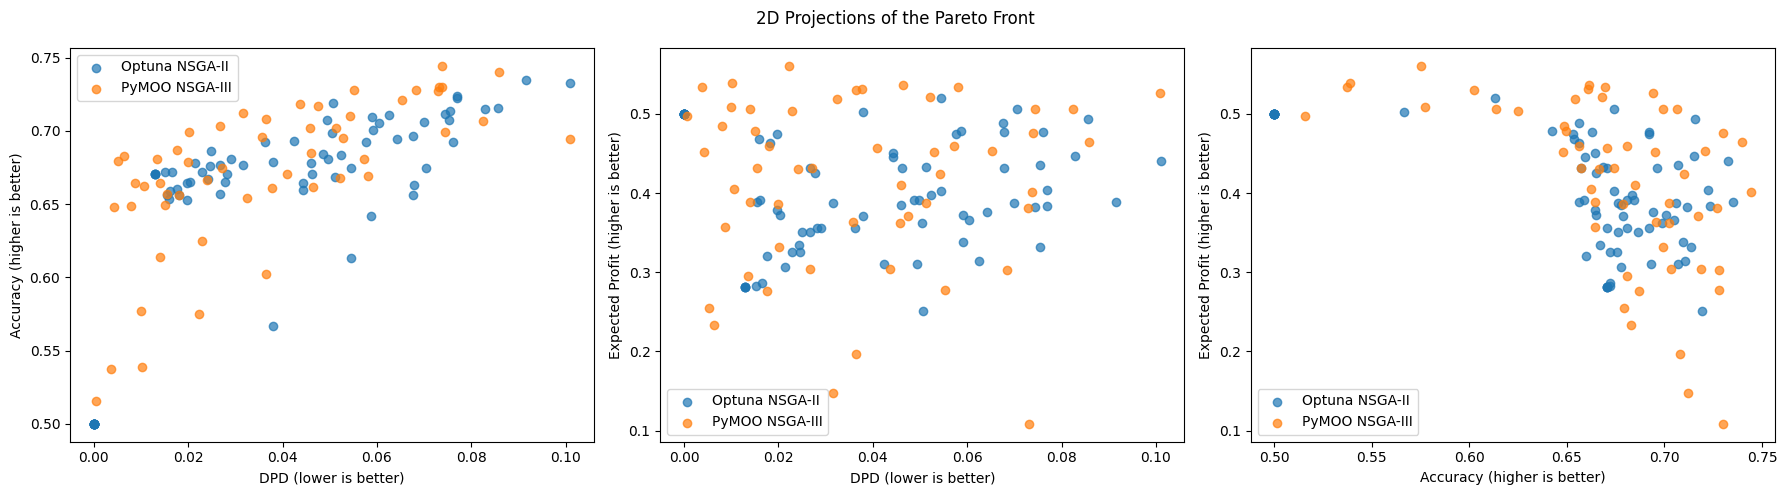

In [5]:
# Combine results
df_all = pd.concat([df_optuna, df_pymoo], ignore_index=True)
df_all.to_csv('data/moo_pareto_fronts.csv', index=False)

# 1. 3D Pareto Front
fig = px.scatter_3d(
    df_all, x='DPD', y='Accuracy', z='Profit',
    color='Algorithm', symbol='Algorithm',
    hover_data=['alpha_fair', 'threshold'],
    title='3D Pareto Front: Optuna NSGA-II vs PyMOO NSGA-III'
)
fig.update_layout(scene=dict(
    xaxis_title='DPD (Minimize)',
    yaxis_title='Accuracy (Maximize)',
    zaxis_title='Expected Profit (Maximize)'
))
fig.write_html("plots/3d_pareto_front.html")
fig.show()

# 2. Parallel Coordinates
fig2 = px.parallel_coordinates(
    df_all,
    dimensions=['alpha_fair', 'threshold', 'DPD', 'Accuracy', 'Profit'],
    color='Profit',
    title='Parallel Coordinates Plot of Pareto Solutions'
)
fig2.write_html("plots/parallel_coordinates.html")
fig2.show()

# 3. 2D Projections
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for alg in ['Optuna NSGA-II', 'PyMOO NSGA-III']:
    subset = df_all[df_all['Algorithm'] == alg]
    
    axes[0].scatter(subset['DPD'], subset['Accuracy'], label=alg, alpha=0.7)
    axes[0].set_xlabel('DPD (lower is better)'); axes[0].set_ylabel('Accuracy (higher is better)')
    
    axes[1].scatter(subset['DPD'], subset['Profit'], label=alg, alpha=0.7)
    axes[1].set_xlabel('DPD (lower is better)'); axes[1].set_ylabel('Expected Profit (higher is better)')
    
    axes[2].scatter(subset['Accuracy'], subset['Profit'], label=alg, alpha=0.7)
    axes[2].set_xlabel('Accuracy (higher is better)'); axes[2].set_ylabel('Expected Profit (higher is better)')

axes[0].legend(); axes[1].legend(); axes[2].legend()
plt.suptitle('2D Projections of the Pareto Front')
plt.tight_layout()
plt.savefig('plots/2d_projections.png', dpi=150)
plt.show()
